# Phase 8 — Distance from adequacy: quantile regression on the savings rate

[`walkthrough/phase8.md`](../walkthrough/phase8.md). The binary flag says *whether* a household
misses the 20% benchmark, not *by how much*. Here the conditional median savings rate is
modelled (robust to the long left tail produced by under-reported income) from the deployable
features only, and households are ranked by predicted rupee shortfall,
`max(0, 0.20 - q50) * INCOME`. Out-of-fold under the same PSU-grouped folds as Phase 7.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.base import clone

from savings_goal import config as C
from savings_goal.evaluation.cv import grouped_cv, oof_predict_proba
from savings_goal.evaluation.metrics import capture_at_budget
from savings_goal.features.engineer import spec_from_frame
from savings_goal.io import load_features, write_result
from savings_goal.models.pipeline import load_model_final, xgb_pipeline
from savings_goal.models.regression import pinball_loss, quantile_model, rupee_shortfall

df = load_features()
spec = spec_from_frame(df)
num = spec.deployable_numeric
cols = num + C.CATEGORICALS
y_rate, y_cls, groups = df["Savings_Rate"], df["Goal_Met"], df[C.GROUP_COL]

q50 = np.full(len(df), np.nan)
const = np.full(len(df), np.nan)
for tr, te in grouped_cv().split(df, y_cls, groups):
    m = clone(quantile_model(num)).fit(df.iloc[tr][cols], y_rate.iloc[tr])
    q50[te] = m.predict(df.iloc[te][cols])
    const[te] = y_rate.iloc[tr].median()
print(f"out-of-fold pinball loss (tau = 0.5): model {pinball_loss(y_rate, q50):.4f}  vs  "
      f"constant median {pinball_loss(y_rate, const):.4f}")
rho = spearmanr(q50, y_rate).statistic
print(f"Spearman(predicted median, actual savings rate) = {rho:.4f}")

out-of-fold pinball loss (tau = 0.5): model 0.4741  vs  constant median 0.7394
Spearman(predicted median, actual savings rate) = 0.7786


## Ranking by predicted rupee shortfall vs the classifier and the income rule

In [2]:
final = load_model_final()
p_cls = oof_predict_proba(xgb_pipeline(num, params=final["deployable"]["best_params"]), df[cols], y_cls, groups)
pred_short = rupee_shortfall(q50, df["INCOME"].to_numpy())
actual_short = np.clip(C.THRESHOLD - y_rate.to_numpy(), 0, None) * df["INCOME"].to_numpy()
at_risk = (1 - y_cls).to_numpy()
rng = np.random.default_rng(C.SEED)
scores = {
    "Predicted rupee shortfall (q50)": pred_short + rng.random(len(df)) * 1e-6,
    "Classifier at-risk score": 1 - p_cls,
    "Income rule (poorest first)": -df["INCOME"].to_numpy() + rng.random(len(df)) * 1e-6,
}
rows = []
for b in (0.10, 0.25, 0.50):
    for name, s in scores.items():
        cap, prec = capture_at_budget(at_risk, s, b)
        rupees, _ = capture_at_budget(actual_short, s, b)  # share of the total rupee gap reached
        rows.append({"budget": b, "strategy": name, "at-risk captured": cap, "precision": prec,
                     "share of total rupee gap reached": rupees})
rank_tbl = pd.DataFrame(rows)
print(rank_tbl.pivot(index="strategy", columns="budget",
                     values=["at-risk captured", "share of total rupee gap reached"]).round(4).to_string())
rho_short = spearmanr(pred_short[at_risk == 1], actual_short[at_risk == 1]).statistic
print(f"\namong at-risk households, Spearman(predicted, actual rupee shortfall) = {rho_short:.4f}")

                                at-risk captured                 share of total rupee gap reached                
budget                                      0.10    0.25    0.50                             0.10    0.25    0.50
strategy                                                                                                         
Classifier at-risk score                  0.1466  0.3618  0.6854                           0.1698  0.3703  0.6455
Income rule (poorest first)               0.1437  0.3504  0.6583                           0.1237  0.2873  0.5470
Predicted rupee shortfall (q50)           0.1427  0.3503  0.6707                           0.2369  0.4546  0.6956

among at-risk households, Spearman(predicted, actual rupee shortfall) = 0.3096


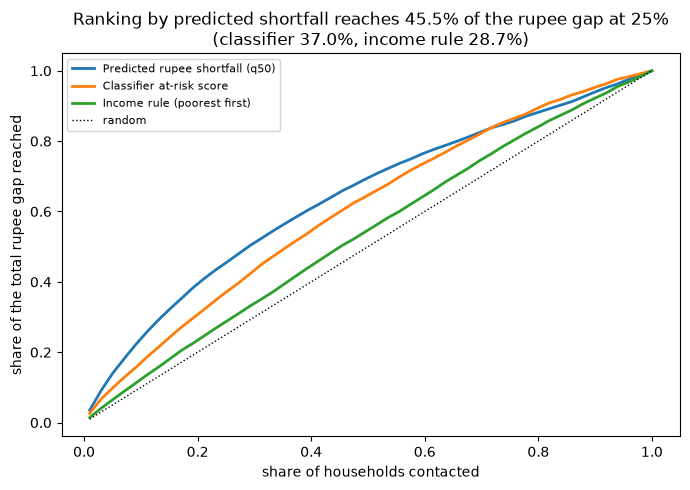

wrote results/savings_rate_regression.json


In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
frac = np.linspace(0.01, 1, 50)
for name, s in scores.items():
    ax.plot(frac, [capture_at_budget(actual_short, s, f)[0] for f in frac], lw=2, label=name)
ax.plot(frac, frac, "k:", lw=1, label="random")
ax.set_xlabel("share of households contacted")
ax.set_ylabel("share of the total rupee gap reached")
r25 = rank_tbl[rank_tbl["budget"] == 0.25].set_index("strategy")["share of total rupee gap reached"]
ax.set_title(f"Ranking by predicted shortfall reaches {r25.iloc[0]:.1%} of the rupee gap at 25%\n"
             f"(classifier {r25.iloc[1]:.1%}, income rule {r25.iloc[2]:.1%})")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(C.RESULTS / "savings_rate_regression.png", dpi=150, bbox_inches="tight")
plt.show()

write_result("savings_rate_regression", {
    "pinball_model": pinball_loss(y_rate, q50), "pinball_constant": pinball_loss(y_rate, const),
    "spearman_rate": rho, "spearman_shortfall_at_risk": rho_short, "ranking": rank_tbl,
    "features": cols,
})
print("wrote results/savings_rate_regression.json")